# ***Intro:***
One of the Kaggle contests is about the TITANIC dataset. You can find every information you want with the link below.

https://www.kaggle.com/competitions/titanic

In [ ]:
#Load dataset
from google.colab import files
upload = files.upload()

Saving titanic.zip to titanic (2).zip


In [ ]:
!unzip titanic.zip

Archive:  titanic.zip
replace gender_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: gender_submission.csv   
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: test.csv                
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: train.csv               


As we see in this zip we have 3 files with names: Gender_submission , Test and Train.
Now is time to work on dataset.

# ***Implementation:***

In [ ]:
#Collect datas
import numpy as np
import pandas as pd
import matplotlib as plt
df =pd.read_csv("gender_submission.csv")
df.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [ ]:
TrainSet = pd.read_csv('./train.csv', index_col = 0)
TestSet = pd.read_csv('./test.csv', index_col = 0)

In [ ]:
TrainSet.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#Data clearing
#Collecting the columns with missing values
print("We can see that 3 columns have a missing values.\n" , TrainSet.isnull().sum())
print("")
a = 100 * TrainSet.isnull().sum()
b = len(TrainSet)
print("The percentage of missing data in each column: \n" , a/b)

We can see that 3 columns have a missing values.
 Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

The percentage of missing data in each column: 
 Survived     0.000000
Pclass       0.000000
Name         0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Ticket       0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64


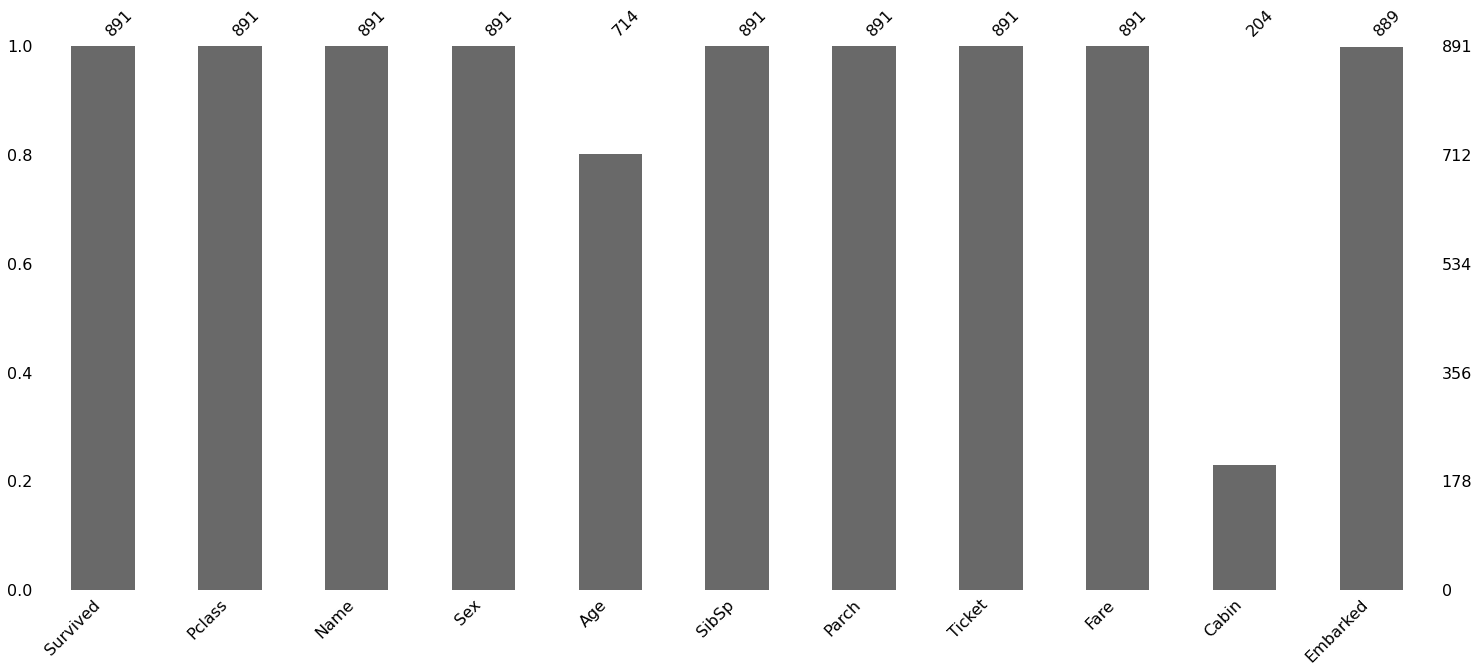

In [ ]:
#Missingno is a  python package especially for visualizing and exploring the missing data of a dataset.
import missingno as msno
msno.bar(TrainSet)

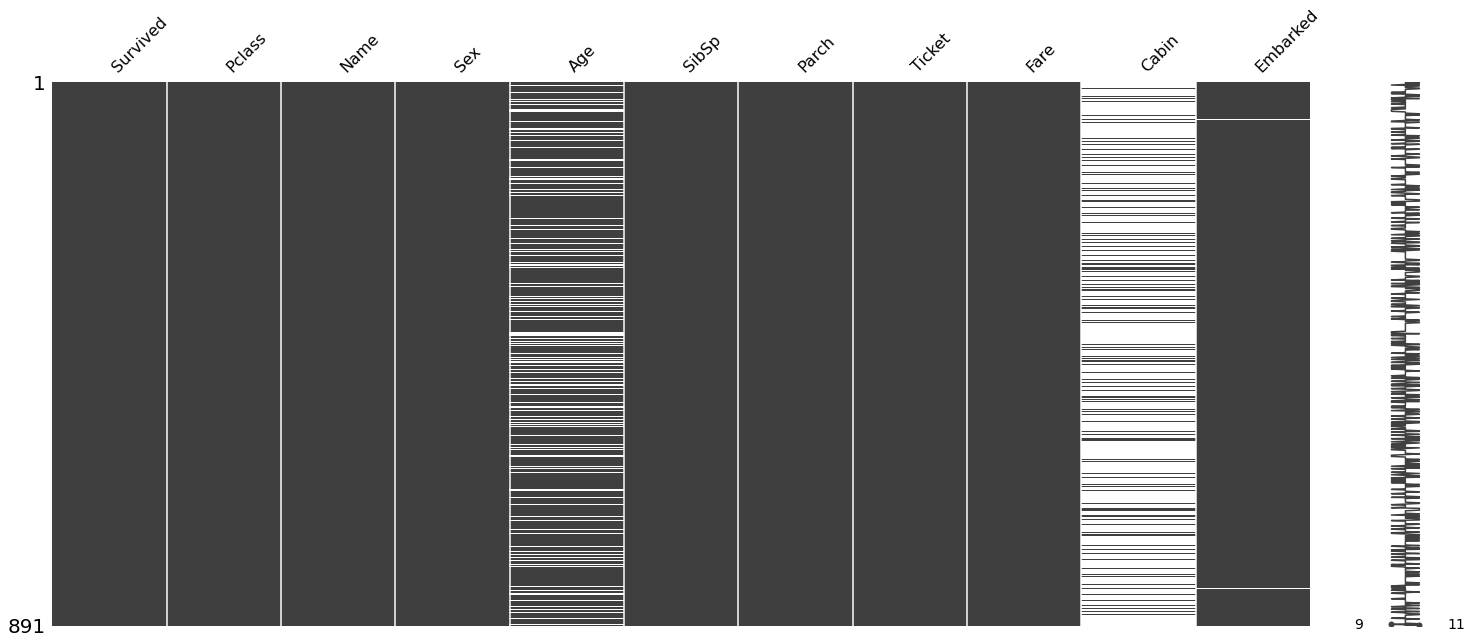

In [ ]:
#Visualization to understand how the missing datas are distributed
msno.matrix(TrainSet)

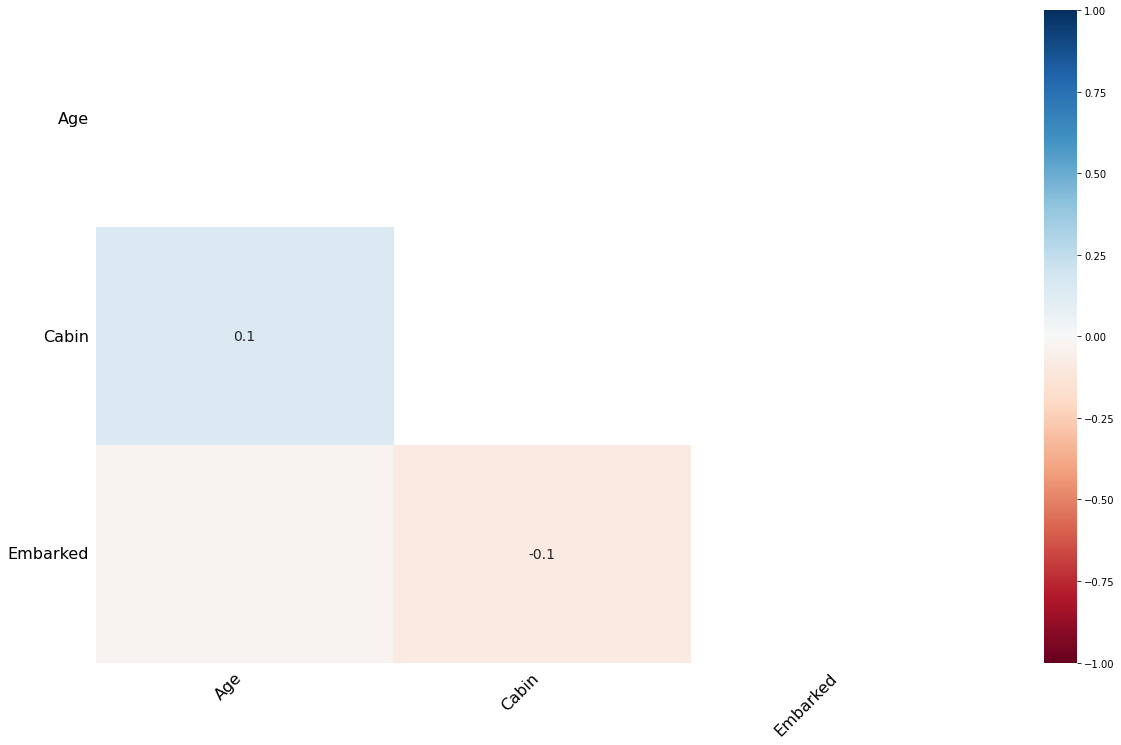

In [ ]:
#To find the correlation (relation) between missing datas from different columns
msno.heatmap(TrainSet)

In [ ]:
TrainSet= pd.get_dummies(TrainSet, columns=['Sex'])
TrainSet.dropna(axis = 0,subset = ['Embarked'], how = 'any', inplace = True)
TrainSet = pd.get_dummies(TrainSet , columns = ['Embarked'])
TrainSet.drop('Name',axis = 'columns', inplace = True)
TrainSet.drop('Cabin',axis = 'columns', inplace = True)
TrainSet.drop('Ticket',axis = 'columns', inplace = True)

In [ ]:
TrainSet.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 1 to 891
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    889 non-null    int64  
 1   Pclass      889 non-null    int64  
 2   Age         712 non-null    float64
 3   SibSp       889 non-null    int64  
 4   Parch       889 non-null    int64  
 5   Fare        889 non-null    float64
 6   Sex_female  889 non-null    uint8  
 7   Sex_male    889 non-null    uint8  
 8   Embarked_C  889 non-null    uint8  
 9   Embarked_Q  889 non-null    uint8  
 10  Embarked_S  889 non-null    uint8  
dtypes: float64(2), int64(4), uint8(5)
memory usage: 53.0 KB


In [ ]:
#Predicting the missing values in the "Age" column with Regression
x_train = TrainSet.loc[TrainSet['Age'].notnull()]
y_train = x_train[['Age']]
x_train = x_train.drop('Age',axis='columns')
x_train = x_train.drop('Survived',axis='columns')

x_test = TrainSet.loc[TrainSet['Age'].isnull()]
x_test = x_test.drop('Age',axis='columns')
x_test = x_test.drop('Survived',axis='columns')

from sklearn.linear_model import LinearRegression
modelLR = LinearRegression()
modelLR.fit(x_train, y_train)
y_pred = modelLR.predict(x_test)

TrainSet.loc[TrainSet['Age'].isnull(), 'Age'] = y_pred

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f10d31c9a10>,
      dtype=object)

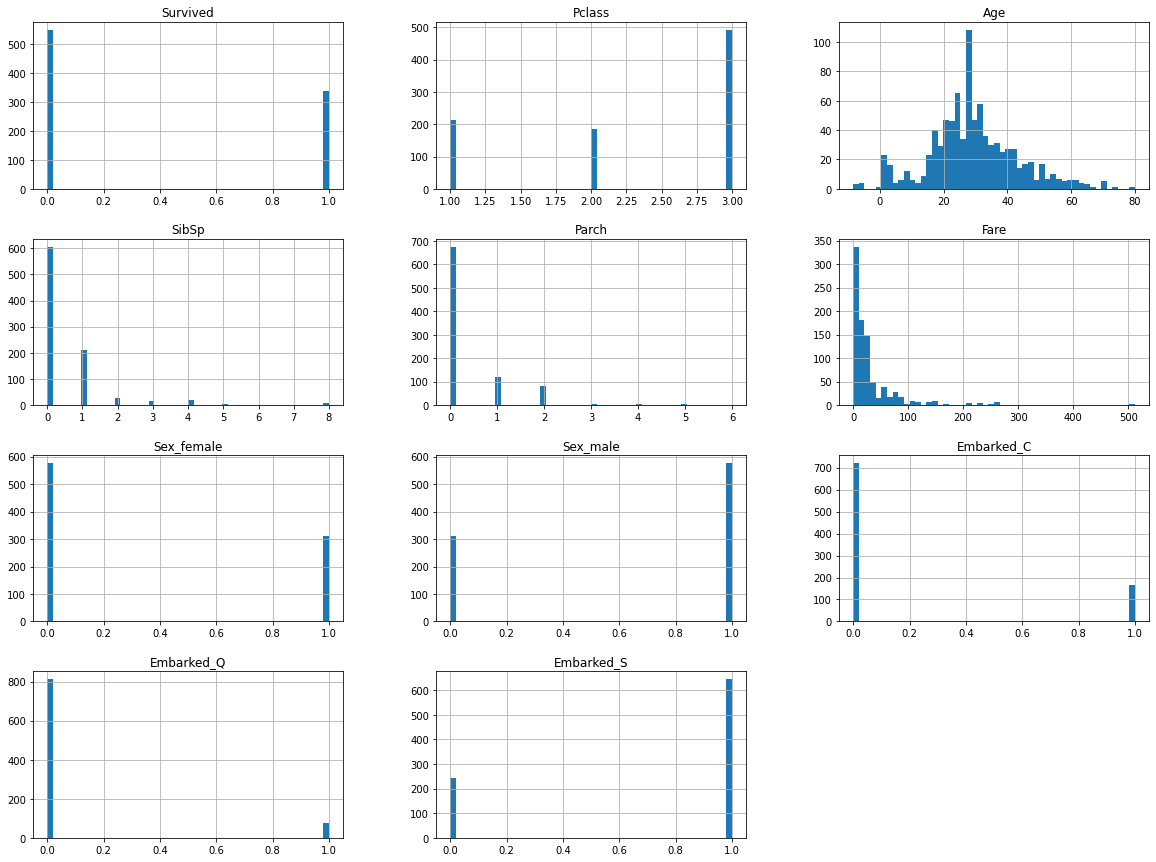

In [ ]:
#Visualization
TrainSet.hist(bins=50, figsize=(20,15))

In [ ]:
#Find correlation
corr_matrix = TrainSet.corr()
corr_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
Survived,1.000000,-0.335549,-0.055385,-0.034040,0.083151,0.255290,0.541585,-0.541585,0.169966,0.004536,-0.151777
Pclass,-0.335549,1.000000,-0.394824,0.081656,0.016824,-0.548193,-0.127741,0.127741,-0.245733,0.220558,0.076466
Age,-0.055385,-0.394824,1.000000,-0.388087,-0.226566,0.083984,-0.117022,0.117022,0.031378,-0.017412,-0.016532
SibSp,-0.034040,0.081656,-0.388087,1.000000,0.414542,0.160887,0.116348,-0.116348,-0.060074,-0.026692,0.069438
Parch,0.083151,0.016824,-0.226566,0.414542,1.000000,0.217532,0.247508,-0.247508,-0.011588,-0.081585,0.061512
Fare,0.255290,-0.548193,0.083984,0.160887,0.217532,1.000000,0.179958,-0.179958,0.270731,-0.116684,-0.163758
Sex_female,0.541585,-0.127741,-0.117022,0.116348,0.247508,0.179958,1.000000,-1.000000,0.084520,0.075217,-0.121405
Sex_male,-0.541585,0.127741,0.117022,-0.116348,-0.247508,-0.179958,-1.000000,1.000000,-0.084520,-0.075217,0.121405
Embarked_C,0.169966,-0.245733,0.031378,-0.060074,-0.011588,0.270731,0.084520,-0.084520,1.000000,-0.148646,-0.782613
Embarked_Q,0.004536,0.220558,-0.017412,-0.026692,-0.081585,-0.116684,0.075217,-0.075217,-0.148646,1.000000,-0.499261


In [ ]:
corr_matrix["Survived"].sort_values(ascending=False)
corr_matrix  #We can easily understand that female passangers are more likely to survive.

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
Survived,1.000000,-0.335549,-0.055385,-0.034040,0.083151,0.255290,0.541585,-0.541585,0.169966,0.004536,-0.151777
Pclass,-0.335549,1.000000,-0.394824,0.081656,0.016824,-0.548193,-0.127741,0.127741,-0.245733,0.220558,0.076466
Age,-0.055385,-0.394824,1.000000,-0.388087,-0.226566,0.083984,-0.117022,0.117022,0.031378,-0.017412,-0.016532
SibSp,-0.034040,0.081656,-0.388087,1.000000,0.414542,0.160887,0.116348,-0.116348,-0.060074,-0.026692,0.069438
Parch,0.083151,0.016824,-0.226566,0.414542,1.000000,0.217532,0.247508,-0.247508,-0.011588,-0.081585,0.061512
Fare,0.255290,-0.548193,0.083984,0.160887,0.217532,1.000000,0.179958,-0.179958,0.270731,-0.116684,-0.163758
Sex_female,0.541585,-0.127741,-0.117022,0.116348,0.247508,0.179958,1.000000,-1.000000,0.084520,0.075217,-0.121405
Sex_male,-0.541585,0.127741,0.117022,-0.116348,-0.247508,-0.179958,-1.000000,1.000000,-0.084520,-0.075217,0.121405
Embarked_C,0.169966,-0.245733,0.031378,-0.060074,-0.011588,0.270731,0.084520,-0.084520,1.000000,-0.148646,-0.782613
Embarked_Q,0.004536,0.220558,-0.017412,-0.026692,-0.081585,-0.116684,0.075217,-0.075217,-0.148646,1.000000,-0.499261


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f10d272e410>,
      dtype=object)

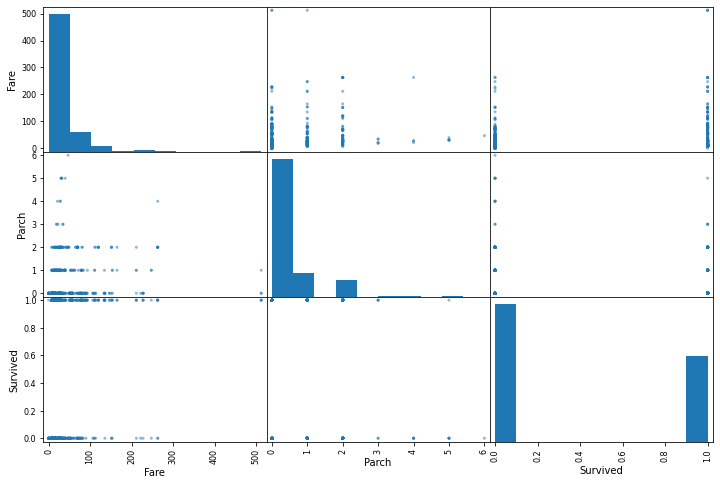

In [ ]:
from pandas.plotting import scatter_matrix
attributes = ["Fare", "Parch","Survived"]
scatter_matrix(TrainSet[attributes], figsize=(12, 8))

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f10d231bb10>,
      dtype=object)

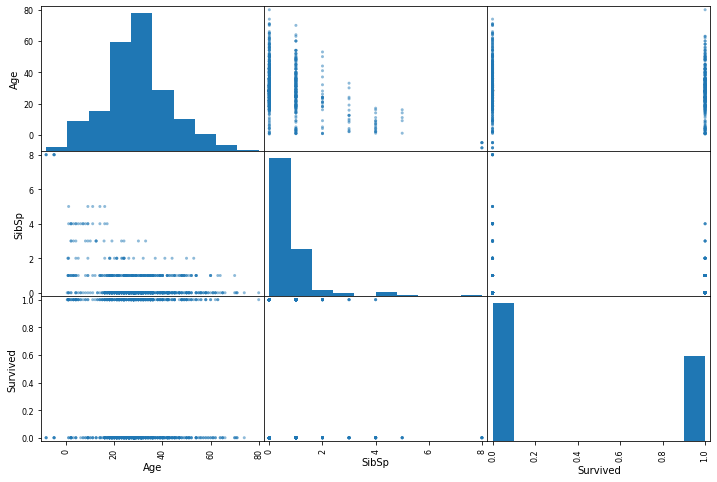

In [ ]:
from pandas.plotting import scatter_matrix
attributes = ["Age", "SibSp","Survived"]
scatter_matrix(TrainSet[attributes], figsize=(12, 8))

In [ ]:
#Building Linear regression model
from sklearn.linear_model import LogisticRegression
X = TrainSet.drop('Survived',axis = 'columns');
y = TrainSet[['Survived']].values.ravel()
model = LogisticRegression(solver = 'newton-cg', max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000, solver='newton-cg')

In [ ]:
#Test the model
TestSet = pd.get_dummies(TestSet, columns = ['Sex'])
TestSet = TestSet.dropna(axis = 0,subset = ['Embarked'], how = 'any')
TestSet = pd.get_dummies(TestSet, columns = ['Embarked'])
TestSet = TestSet.drop('Name',axis = 'columns')
TestSet = TestSet.drop('Cabin',axis = 'columns')
TestSet = TestSet.drop('Ticket',axis = 'columns')
TestSet['Fare'] = TestSet['Fare'].replace(np.NaN , TrainSet['Fare'].median())
x_test = TestSet.loc[TestSet['Age'].isnull()]
x_test = x_test.drop('Age',axis = 'columns')
TestSet.loc[TestSet['Age'].isnull(), 'Age'] = modelLR.predict(x_test)
test_pred = model.predict(TestSet)
submission = pd.DataFrame(test_pred)
submission

,0
0,0
1,0
2,0
3,0
4,1
...,...
413,0
414,1
415,0
416,0


**Now we find who survived :)**